# Exploratory Data Analysis

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import Librairies

In [2]:
!pip install keras_cv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 48.5 MB/s eta 0:00:00


In [3]:
!pip install tensorflow_io

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 56.4 MB/s eta 0:00:00


JAX : Known for its speed and ability to perform differentiable computations very efficiently. Offers advanced features like automatic vectorization and automatic differentiation. Ideal for projects requiring fast optimization or GPU/TPU experiments. Default: TensorFlow

In [4]:
import os
os.environ["KERAS_BACKEND"] = "jax"  # "jax" or "tensorflow" or "torch"

import keras_cv
import keras
import keras.backend as K
import tensorflow as tf
import tensorflow_io as tfio

import numpy as np
import pandas as pd

from glob import glob
from tqdm import tqdm

import librosa
import IPython.display as ipd
from IPython.display import Audio as ipd_Audio
import librosa.display as lid

import matplotlib.pyplot as plt
import matplotlib as mpl

cmap = mpl.colormaps['coolwarm']

import seaborn as sns

/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl5mutex6unlockEv']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZN3tsl7strings13safe_strtou64ESt17basic_string_viewIcSt11char_traitsIcEEPm']
  warnings.warn(

In [5]:
from sklearn.model_selection import train_test_split

Library Version

In [6]:
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("KerasCV:", keras_cv.__version__)

TensorFlow: 2.19.0
Keras: 3.10.0
KerasCV: 0.9.0


## EDA on raw audio

## Define input files paths ###

In [26]:
DRIVE_PATH = '/content/drive'
MYDRIVE_PATH = os.path.join(DRIVE_PATH, 'MyDrive/')
TARGET_DIR = os.path.join(MYDRIVE_PATH, 'dsfs-ft-31', 'alzheimer_data/')
TRAIN_AUDIOS_WAV_DIR = os.path.join(TARGET_DIR , 'train_audios','wav/')
print(f'TRAIN_AUDIOS_WAV_DIR : {TRAIN_AUDIOS_WAV_DIR}')
TEST_AUDIOS_WAV_DIR = os.path.join(TARGET_DIR, 'test_audios','wav/')
LABELS_DIR = os.path.join(TARGET_DIR, 'labels/')
TRAIN_LABELS_FILE_PATH = LABELS_DIR + 'train_labels.csv'
print(f'TRAIN_LABELS_FILE_PATH : {TRAIN_LABELS_FILE_PATH}')
TEST_LABELS_FILE_PATH = LABELS_DIR + 'test_labels.csv'
METADATA_FILE_PATH = os.path.join(TARGET_DIR, 'metadata', 'metadata.csv')
print(f'METADATA_FILE_PATH : {METADATA_FILE_PATH}')

TRAIN_FEATURES_FILE_PATH = os.path.join(TARGET_DIR, 'features', 'train_features.csv')
print(f'TRAIN_FEATURES_FILE_PATH : {TRAIN_FEATURES_FILE_PATH}')

TRAIN_AUDIOS_WAV_DIR : /content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/wav/
TRAIN_LABELS_FILE_PATH : /content/drive/MyDrive/dsfs-ft-31/alzheimer_data/labels/train_labels.csv
METADATA_FILE_PATH : /content/drive/MyDrive/dsfs-ft-31/alzheimer_data/metadata/metadata.csv
TRAIN_FEATURES_FILE_PATH : /content/drive/MyDrive/dsfs-ft-31/alzheimer_data/features/train_features.csv


### Configuration

In [8]:
import os
import pandas as pd

class CFG:
    # Random seed for reproducibility
    seed = 42

    # Input audio settings
    duration = 30  # Maximum audio duration in seconds
    sample_rate = 32000  # Sampling rate in Hz
    audio_len = duration * sample_rate  # Maximum audio length in samples

    # STFT parameters
    nfft = 2048
    window = 2048
    hop_length = audio_len // 128  # Define hop length based on desired spectrogram width
    fmin = 20  # Minimum frequency for spectrogram
    fmax = sample_rate // 2  # Maximum frequency for spectrogram (Nyquist frequency)

    # Training parameters
    img_size = [128, 384]  # Spectrogram image size (height, width)
    batch_size = 64  # Number of samples per batch
    epochs = 10  # Number of training epochs
    model_name = 'efficientnetv2_b2_imagenet'  # Pretrained model to use

    # Data augmentation flag
    augment = True

    # Path to the data
    train_audio_path = TRAIN_AUDIOS_WAV_DIR   # Path to the folder containing .wav files
    labels_csv_path = TRAIN_LABELS_FILE_PATH  # Path to the CSV file with labels

    # Processing the label data
    @staticmethod
    def load_labels():
        """Load and process labels from the CSV file."""
        labels_df = pd.read_csv(CFG.labels_csv_path)

        # Extract unique labels and create mappings
        CFG.class_names = ['diagnosis_control', 'diagnosis_mci', 'diagnosis_adrd']
        CFG.num_classes = len(CFG.class_names)

        # Create mappings for labels
        CFG.class_labels = {label: idx for idx, label in enumerate(CFG.class_names)}
        CFG.label2name = {v: k for k, v in CFG.class_labels.items()}

        return labels_df

    # Example method to map a row in the CSV to a one-hot encoded label
    @staticmethod
    def encode_labels(row):
        """Encode labels into a one-hot format based on the CSV row."""
        return [row['diagnosis_control'], row['diagnosis_mci'], row['diagnosis_adrd']]


Reproducibility

In [9]:
tf.keras.utils.set_random_seed(CFG.seed)

### Metadata

In [15]:
# File Paths
#BASE_PATH = '/content/drive/MyDrive/Projects/S-src-wav/train_audios_wav'
#metadata_path = '/content/drive/MyDrive/Projects/S-src-csv-files/metadata.csv'
#labels_path = '/content/drive/MyDrive/Projects/S-src-csv-files/train_labels.csv'


BASE_PATH = TRAIN_AUDIOS_WAV_DIR
metadata_path = METADATA_FILE_PATH
labels_path = TRAIN_LABELS_FILE_PATH

# Load files
metadata_df = pd.read_csv(metadata_path)  # Contient train et test
labels_df = pd.read_csv(labels_path)     # Contient uniquement les labels pour train

# Separate the train and test sets
train_metadata = metadata_df[metadata_df['split'] == 'train']
test_metadata = metadata_df[metadata_df['split'] == 'test']

# Merge files for train
train_df = pd.merge(train_metadata, labels_df, on='uid', how='inner')

# Add the full path of the audio files
train_df['filepath'] = BASE_PATH  + train_df['uid'] + '.wav'
test_metadata['filepath'] = BASE_PATH  + test_metadata['uid'] + '.wav'

# Prepare train labels (one-hot format)
train_df['target'] = train_df[['diagnosis_control', 'diagnosis_mci', 'diagnosis_adrd']].values.tolist()

# check
print(f"train_df shape : {train_df.shape}")
print(f"test_metadata shape : {test_metadata.shape}")

train_df shape : (1646, 11)
test_metadata shape : (412, 7)


/tmp/ipython-input-2497900048.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_metadata['filepath'] = BASE_PATH  + test_metadata['uid'] + '.wav'


### Check ###

In [16]:
pd.set_option('display.max_colwidth', None)
train_df[['uid','split','filepath']].head(5)

,uid,split,filepath
0,aaop,train,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/wav/aaop.wav
1,abgk,train,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/wav/abgk.wav
2,ablf,train,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/wav/ablf.wav
3,acad,train,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/wav/acad.wav
4,acis,train,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/wav/acis.wav


In [17]:

test_metadata[['uid','split','filepath']].head(5)

,uid,split,filepath
1,aazd,test,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/wav/aazd.wav
5,acdn,test,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/wav/acdn.wav
9,adoi,test,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/wav/adoi.wav
15,agiy,test,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/wav/agiy.wav
16,agni,test,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/wav/agni.wav


In [18]:
# Show first lines for verification
print("Train DataFrame:")
display(train_df.head(2))

print("\nTest DataFrame:")
display(test_metadata.head(2))

Train DataFrame:


,uid,age,gender,split,hash,filesize_kb,diagnosis_control,diagnosis_mci,diagnosis_adrd,filepath,target
0,aaop,72,female,train,e4ed5943c8460c2cf324d4a23c7d6fa1,186.144,0.0,1.0,0.0,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/wav/aaop.wav,"[0.0, 1.0, 0.0]"
1,abgk,80,male,train,c6ca4b23c8a920a6ac950dbec2b58059,136.368,1.0,0.0,0.0,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/wav/abgk.wav,"[1.0, 0.0, 0.0]"



Test DataFrame:


,uid,age,gender,split,hash,filesize_kb,filepath
1,aazd,82,male,test,fc7ef901807e2fb07cfedde8545a7fec,292.272,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/wav/aazd.wav
5,acdn,82,male,test,0bb02c09dee7e725928b7dbf6d8bf4ec,266.304,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/wav/acdn.wav


In [19]:
train_df.columns

Index(['uid', 'age', 'gender', 'split', 'hash', 'filesize_kb',
       'diagnosis_control', 'diagnosis_mci', 'diagnosis_adrd', 'filepath',
       'target'],
      dtype='object')

### Functions for visualization

In [20]:
# Load function to play audio file
def load_audio(filepath):
    audio, sr = librosa.load(filepath, sr=CFG.sample_rate)  # Forcer le sample rate depuis CFG
    return audio, sr

In [21]:
# Function to obtain the spectrogram
def get_spectrogram(audio):
    # Calculate the melspectrogram
    spec = librosa.feature.melspectrogram(
        y=audio,
        sr=CFG.sample_rate,
        n_mels=256,
        n_fft=CFG.nfft,
        hop_length=CFG.hop_length,
        fmax=CFG.fmax,
        fmin=CFG.fmin,
    )
    # Convert to decibel scale
    spec = librosa.power_to_db(spec, ref=1.0)
    # Normalization between 0 and 1
    min_ = spec.min()
    max_ = spec.max()
    if max_ != min_:
        spec = (spec - min_) / (max_ - min_)
    return spec

In [22]:
# Function to display an audio file and its spectrogram
def display_audio(row):
    # Building the legend
    caption = (
        f"ID: {row.uid} | Age: {row.age} | Gender: {row.gender}\n"
        f"Diagnosis (Control, MCI, ADRD): [{row.diagnosis_control}, {row.diagnosis_mci}, {row.diagnosis_adrd}]"
    )
    # Load audio
    audio, sr = load_audio(row.filepath)
    # Cut audio to the specified maximum duration
    audio = audio[:CFG.audio_len]
    # Get the spectrogram
    spec = get_spectrogram(audio)

    # Show audio
    print("# Audio:")
    display(ipd_Audio(audio, rate=CFG.sample_rate))

    # Show visualizations
    print("# Visualization:")
    fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True, tight_layout=True)
    fig.suptitle(caption, fontsize=14)

    # Show audio wave
    lid.waveshow(audio, sr=CFG.sample_rate, ax=ax[0], color="blue")
    ax[0].set_title("Waveform")

    # Show spectrogram
    lid.specshow(
        spec,
        sr=CFG.sample_rate,
        hop_length=CFG.hop_length,
        x_axis="time",
        y_axis="mel",
        cmap="coolwarm",
        ax=ax[1]
    )
    ax[1].set_title("Mel Spectrogram")

    plt.show()

#### Sample 1

# Audio:


# Visualization:


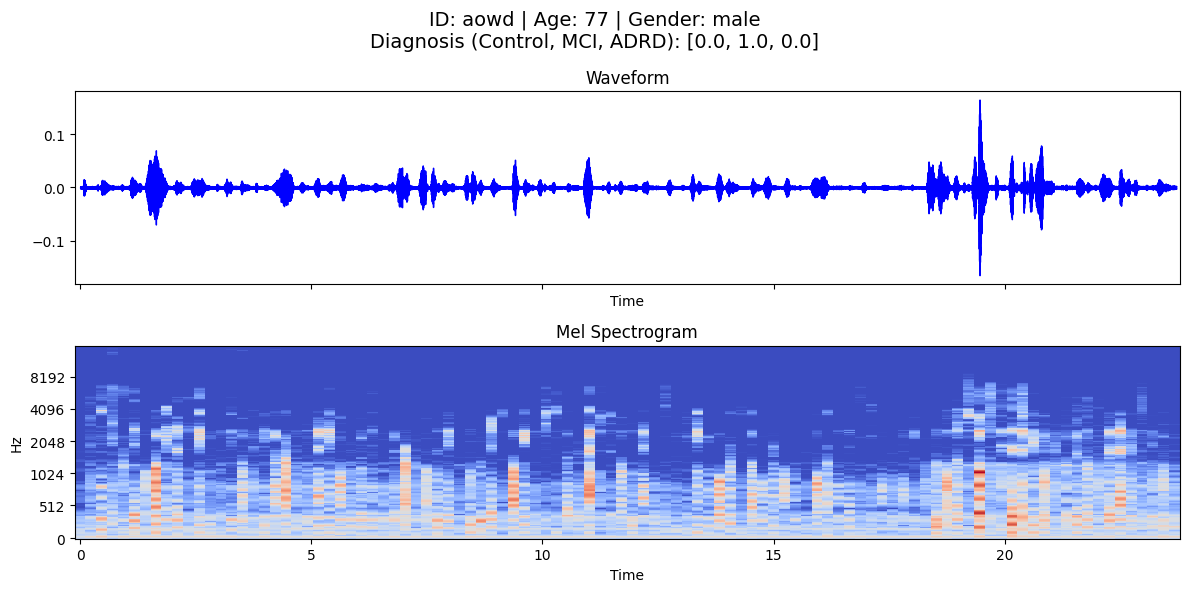

In [23]:
# Example of use with a specific line
row = train_df.iloc[35]  # Line 35 of the DataFrame
display_audio(row)

#### Sample 2

# Audio:


# Visualization:


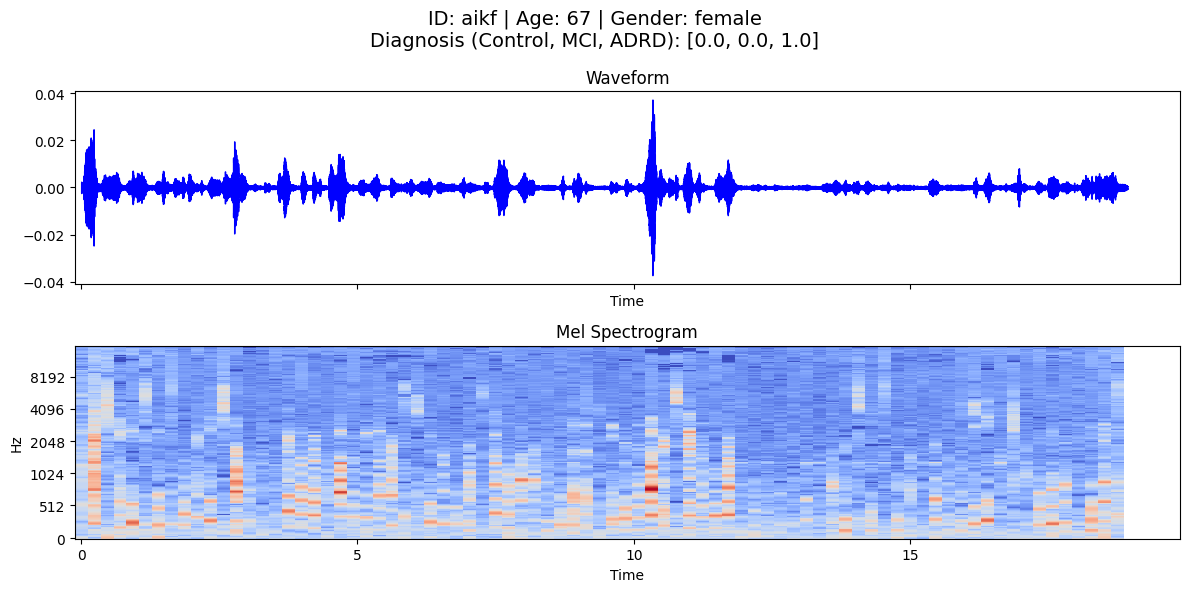

In [24]:
# Example of use with a specific line
row = train_df.iloc[16]  # Line 16 of the DataFrame
display_audio(row)

#### Sample 3

# Audio:


# Visualization:


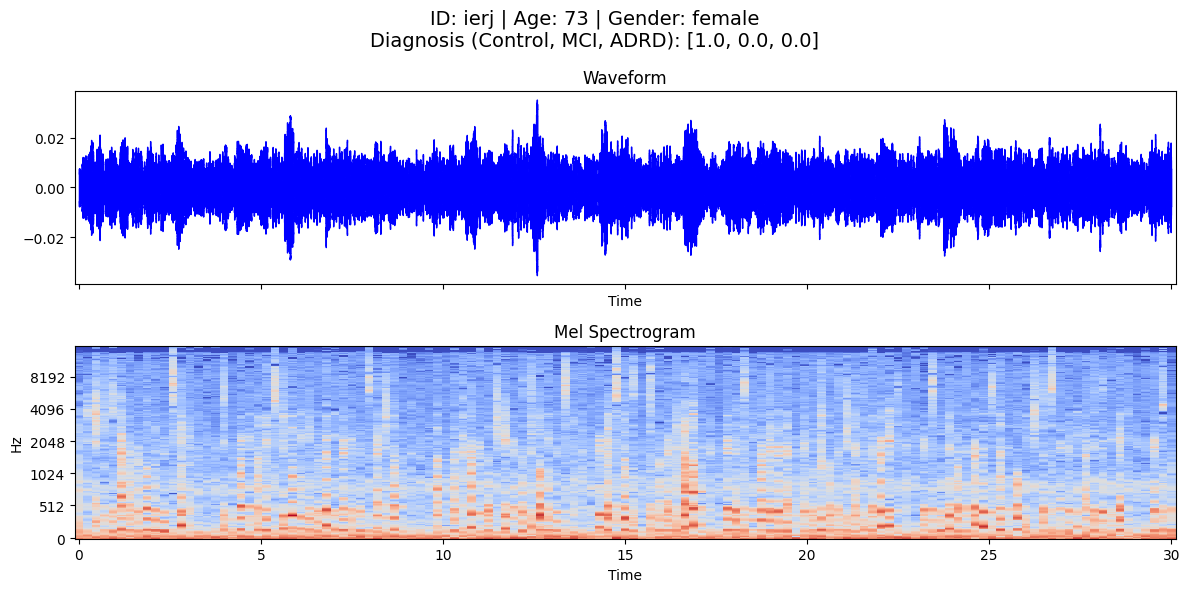

In [25]:
# Example of use with a specific line
row = train_df.iloc[500]  # Line 500 of the DataFrame
display_audio(row)

## EDA on pre-extracted features of audio files

### About train set

In [27]:
#train_features = pd.read_csv("/content/drive/MyDrive/Projects/S-src-csv-files/train_features.csv")
train_features = pd.read_csv(TRAIN_FEATURES_FILE_PATH)
print("CSV file : train_features")
print()
display(train_features.head())
print()
print(f"Shape of train_features : {train_features.shape}")
print()
print("Basics staitistics :")
display(train_features.describe(include='all'))
print()
print("Percentage of missing values :")
display(100 * train_features.isnull().sum() /train_features.shape[0])
print()
duplicate_rows = train_features[train_features.duplicated()]
print(f"Number of duplicates: {duplicate_rows.shape[0]}")

CSV file : train_features



,uid,segment_start_sec,segment_end_sec,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
0,aaop,0.0,0.2,38.605347,0.009719,38.243042,38.758526,38.892136,0.649094,9.977150,...,0.0,0.0,0.0,0.000000,7.692308,0.12,0.0,0.0,0.0,-15.069119
1,aaop,0.1,0.3,15.119725,0.109019,13.862534,13.973801,15.657784,1.795250,104.583500,...,0.0,0.0,0.0,5.263158,7.692308,0.12,0.0,0.0,0.0,-15.477599
2,aaop,0.2,0.4,19.612692,0.034823,19.340792,19.570105,19.640610,0.299818,8.293267,...,0.0,0.0,0.0,0.000000,9.090909,0.10,0.0,0.0,0.0,-20.027859
3,aaop,0.3,0.5,26.474092,0.083448,25.653616,26.754297,28.361671,2.708055,424.170140,...,0.0,0.0,0.0,5.263158,7.692308,0.12,0.0,0.0,0.0,-23.567434
4,aaop,0.4,0.6,26.250055,0.009512,26.163984,26.272215,26.469680,0.305696,30.626870,...,0.0,0.0,0.0,0.000000,7.692308,0.12,0.0,0.0,0.0,-28.968897



Shape of train_features : (158810, 91)

Basics staitistics :


,uid,segment_start_sec,segment_end_sec,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
count,158810,158810.000000,158810.000000,158810.000000,158810.000000,158810.000000,158810.000000,158810.000000,158810.000000,158810.000000,...,158809.000000,158809.000000,158809.000000,158809.000000,158809.000000,158809.000000,158809.000000,158809.000000,158809.000000,158809.000000
unique,599,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,acad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,13.822802,14.022277,22.152692,0.050482,21.067880,22.289499,23.228077,2.160197,37.437483,...,-0.006056,-0.004400,0.131951,5.093894,6.677461,0.076108,0.000377,0.034450,0.000168,-38.433711
std,NaN,8.411044,8.410365,12.107132,0.078689,11.927822,12.278235,12.630849,4.044614,104.958858,...,0.048637,0.008010,0.397988,3.746833,3.682508,0.047961,0.002430,0.046605,0.001598,13.222692
min,NaN,0.000000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-703.620200,...,-0.206966,-0.062029,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-107.343900
25%,NaN,6.600000,6.800000,16.046470,0.003346,14.269415,15.602151,16.965292,0.136545,0.000000,...,-0.015825,-0.008291,0.000000,5.263158,7.142857,0.030000,0.000000,0.000000,0.000000,-45.250820
50%,NaN,13.300000,13.500000,24.791701,0.016612,23.170750,25.122540,26.410858,0.637413,0.772972,...,0.000000,0.000000,0.005746,5.263158,7.692308,0.100000,0.000000,0.000000,0.000000,-38.040890
75%,NaN,20.800000,21.000000,30.999929,0.055929,30.342620,31.351320,32.124424,1.939703,20.780961,...,0.006061,0.000000,0.102996,5.263158,7.692308,0.120000,0.000000,0.060000,0.000000,-28.866669



Percentage of missing values :


,0
uid,0.00000
segment_start_sec,0.00000
segment_end_sec,0.00000
F0semitoneFrom27.5Hz_sma3nz_amean,0.00000
F0semitoneFrom27.5Hz_sma3nz_stddevNorm,0.00000
...,...
MeanVoicedSegmentLengthSec,0.00063
StddevVoicedSegmentLengthSec,0.00063
MeanUnvoicedSegmentLength,0.00063
StddevUnvoicedSegmentLength,0.00063



Number of duplicates: 0


### About test set

In [ ]:
test_features = pd.read_csv("/content/drive/MyDrive/Projects/S-src-csv-files/test_features.csv")

print("CSV file : test_features")
print()
display(test_features.head())
print()
print(f"Shape of test_features : {test_features.shape}")
print()
print("Basics staitistics :")
display(test_features.describe(include='all'))
print()
print("Percentage of missing values :")
display(100 * test_features.isnull().sum() /test_features.shape[0])
print()
duplicate_rows = test_features[test_features.duplicated()]
print(f"Number of duplicates: {duplicate_rows.shape[0]}")

CSV file : test_features



,uid,segment_start_sec,segment_end_sec,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
0,aazd,0.0,0.2,27.936117,0.003336,27.848993,27.918620,28.015140,0.166147,5.076218,...,0.000000,0.000000,0.000000,5.263158,7.692308,0.12,0.0,0.00,0.0,-18.887548
1,aazd,0.1,0.3,30.740181,0.083920,28.242626,29.990292,33.503980,5.261353,0.524649,...,0.000000,0.000000,0.000000,10.526316,7.142857,0.13,0.0,0.00,0.0,-20.103893
2,aazd,0.2,0.4,31.624413,0.175349,26.634650,34.048250,35.661823,9.027174,62.070404,...,0.000000,0.000000,0.000000,5.263158,9.090909,0.10,0.0,0.00,0.0,-21.896103
3,aazd,0.3,0.5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.110255,-0.014374,0.667024,0.000000,0.000000,0.00,0.0,0.12,0.0,-21.512558
4,aazd,0.4,0.6,25.034302,0.193084,19.844713,28.462542,28.667650,8.822937,1.203319,...,-0.144730,-0.011132,0.705468,5.263158,7.692308,0.09,0.0,0.02,0.0,-20.662850



Shape of test_features : (111068, 91)

Basics staitistics :


,uid,segment_start_sec,segment_end_sec,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
count,111068,111068.000000,111068.000000,111068.000000,111068.000000,111068.000000,111068.000000,111068.000000,111068.000000,111068.000000,...,111068.000000,111068.000000,111068.000000,111068.000000,111068.000000,111068.000000,111068.000000,111068.000000,111068.000000,111068.000000
unique,412,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,bkpm,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,13.932921,14.132422,22.802134,0.050428,21.705665,22.937842,23.892544,2.186880,38.197648,...,-0.006391,-0.004258,0.128429,5.131854,6.784910,0.077557,0.000369,0.032871,0.000158,-38.044243
std,NaN,8.426807,8.426119,12.021381,0.078350,11.855074,12.185613,12.542733,4.067627,107.183576,...,0.049233,0.008043,0.384826,3.747425,3.612627,0.047271,0.002398,0.045607,0.001551,13.010428
min,NaN,0.000000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-526.465450,...,-0.179085,-0.066130,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-120.000000
25%,NaN,6.700000,6.900000,16.967566,0.003792,14.819629,16.518240,18.061478,0.155275,0.000000,...,-0.014557,-0.008069,0.000000,5.263158,7.142857,0.035000,0.000000,0.000000,0.000000,-44.854702
50%,NaN,13.500000,13.700000,25.552552,0.016895,23.993357,25.934561,27.319454,0.656761,1.190342,...,0.000000,0.000000,0.004374,5.263158,7.692308,0.100000,0.000000,0.000000,0.000000,-37.965867
75%,NaN,20.900000,21.100000,31.220002,0.055630,30.601932,31.499823,32.262166,1.965308,22.042633,...,0.000951,0.000000,0.100495,5.263158,7.692308,0.120000,0.000000,0.060000,0.000000,-28.516960



Percentage of missing values :


,0
uid,0.0
segment_start_sec,0.0
segment_end_sec,0.0
F0semitoneFrom27.5Hz_sma3nz_amean,0.0
F0semitoneFrom27.5Hz_sma3nz_stddevNorm,0.0
...,...
MeanVoicedSegmentLengthSec,0.0
StddevVoicedSegmentLengthSec,0.0
MeanUnvoicedSegmentLength,0.0
StddevUnvoicedSegmentLength,0.0



Number of duplicates: 0


### About labes

In [28]:
train_labels = pd.read_csv(TRAIN_LABELS_FILE_PATH)
print("CSV file : train_labels")
print()
print(f"Shape of train_labels : {train_labels.shape}")
print()
display(train_labels.head())
print()
print(f"Shape of train_labels : {train_labels.shape}")
print()
print("Basics staitistics :")
display(train_labels.describe(include='all'))
print()
print("Percentage of missing values :")
display(100 * train_labels.isnull().sum() /train_labels.shape[0])
print()
duplicate_rows = train_labels[train_labels.duplicated()]
print(f"Number of duplicates: {duplicate_rows.shape[0]}")

CSV file : train_labels

Shape of train_labels : (1646, 4)



,uid,diagnosis_control,diagnosis_mci,diagnosis_adrd
0,aaop,0.0,1.0,0.0
1,abgk,1.0,0.0,0.0
2,ablf,1.0,0.0,0.0
3,acad,1.0,0.0,0.0
4,acis,0.0,1.0,0.0



Shape of train_labels : (1646, 4)

Basics staitistics :


,uid,diagnosis_control,diagnosis_mci,diagnosis_adrd
count,1646,1646.000000,1646.000000,1646.000000
unique,1646,NaN,NaN,NaN
top,zznq,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,0.553463,0.131835,0.314702
std,NaN,0.497285,0.338414,0.464538
min,NaN,0.000000,0.000000,0.000000
25%,NaN,0.000000,0.000000,0.000000
50%,NaN,1.000000,0.000000,0.000000
75%,NaN,1.000000,0.000000,1.000000



Percentage of missing values :


,0
uid,0.0
diagnosis_control,0.0
diagnosis_mci,0.0
diagnosis_adrd,0.0



Number of duplicates: 0


### Explore one UID

In [29]:
# Filter train_features to show all lines with uid="aazd"
uid_to_filter = "aaop"
filtered_data = train_features[train_features['uid'] == uid_to_filter]

# Displaying filtered lines
print(f"Shape of filtered_data : {filtered_data.shape}")
print()
display(filtered_data)

Shape of filtered_data : (300, 91)



,uid,segment_start_sec,segment_end_sec,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
0,aaop,0.0,0.2,38.605347,0.009719,38.243042,38.758526,38.892136,0.649094,9.977150,...,0.000000,0.000000,0.000000,0.000000,7.692308,0.12,0.0,0.00,0.0,-15.069119
1,aaop,0.1,0.3,15.119725,0.109019,13.862534,13.973801,15.657784,1.795250,104.583500,...,0.000000,0.000000,0.000000,5.263158,7.692308,0.12,0.0,0.00,0.0,-15.477599
2,aaop,0.2,0.4,19.612692,0.034823,19.340792,19.570105,19.640610,0.299818,8.293267,...,0.000000,0.000000,0.000000,0.000000,9.090909,0.10,0.0,0.00,0.0,-20.027859
3,aaop,0.3,0.5,26.474092,0.083448,25.653616,26.754297,28.361671,2.708055,424.170140,...,0.000000,0.000000,0.000000,5.263158,7.692308,0.12,0.0,0.00,0.0,-23.567434
4,aaop,0.4,0.6,26.250055,0.009512,26.163984,26.272215,26.469680,0.305696,30.626870,...,0.000000,0.000000,0.000000,0.000000,7.692308,0.12,0.0,0.00,0.0,-28.968897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,aaop,29.5,29.7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.067632,-0.010967,0.058532,0.000000,0.000000,0.00,0.0,0.12,0.0,-38.647740
296,aaop,29.6,29.8,39.799446,0.004403,39.647533,39.760620,39.941370,0.293835,6.831646,...,0.074498,-0.007974,0.024295,0.000000,7.692308,0.08,0.0,0.03,0.0,-17.002804
297,aaop,29.7,29.9,40.106010,0.005033,39.934730,40.171715,40.276660,0.341930,9.798661,...,0.000000,0.000000,0.000000,5.263158,7.692308,0.12,0.0,0.00,0.0,-13.734057
298,aaop,29.8,30.0,40.483215,0.003475,40.342550,40.462660,40.637318,0.294769,4.207357,...,0.000000,0.000000,0.000000,0.000000,7.692308,0.12,0.0,0.00,0.0,-14.204272


## Analysis

### Class distribution


Class Distribution in Training Set:
class
diagnosis_control    911
diagnosis_adrd       518
diagnosis_mci        217
Name: count, dtype: int64


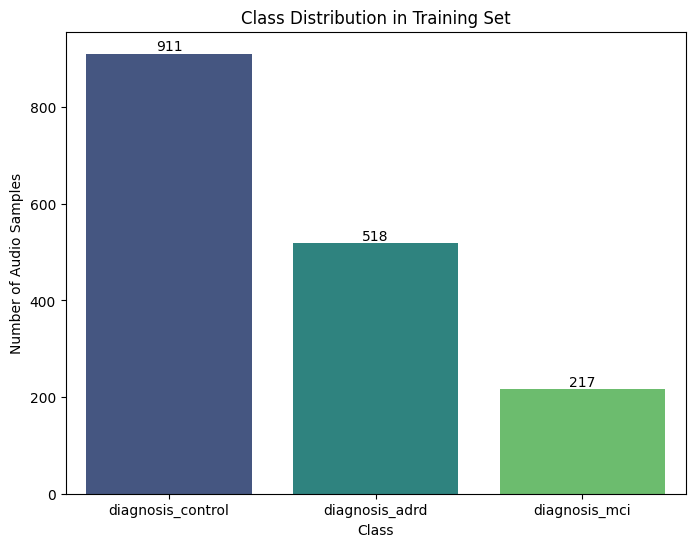

In [30]:
# Base audio directory
train_audio_dir = TRAIN_AUDIOS_WAV_DIR

# Load data
audio_files_with_labels = train_df.copy()  # Using train_df as a base

if not audio_files_with_labels.empty:
    # Add the full path of the audio files
    audio_files_with_labels['file_name'] = audio_files_with_labels['uid'] + '.wav'
    audio_files_with_labels['file_path'] = train_audio_dir + '/' + audio_files_with_labels['file_name']

    # Identify the class for each file based on the highest probability
    audio_files_with_labels['class'] = audio_files_with_labels[['diagnosis_control', 'diagnosis_mci', 'diagnosis_adrd']].idxmax(axis=1)

    # Count the number of samples in each class
    class_counts = audio_files_with_labels['class'].value_counts()

    # Show class distribution
    print("\nClass Distribution in Training Set:")
    print(class_counts)

    # Visualization of class distribution
    plt.figure(figsize=(8, 6))
    sns.barplot(
        x=class_counts.index,
        y=class_counts.values,
        hue=class_counts.index,  # Assign the x variable to hue
        dodge=False,             # Avoid splitting bars
        palette='viridis'        # Keep the color palette
    )
    plt.title('Class Distribution in Training Set')
    plt.xlabel('Class')
    plt.ylabel('Number of Audio Samples')
    plt.legend([],[], frameon=False)  # Disable legend
    for index, value in enumerate(class_counts.values):
        plt.text(index, value, str(value), ha='center', va='bottom')
    plt.show()
else:
    print("No matching audio files found between train_labels and train_audio_dir.")

### Audio duration

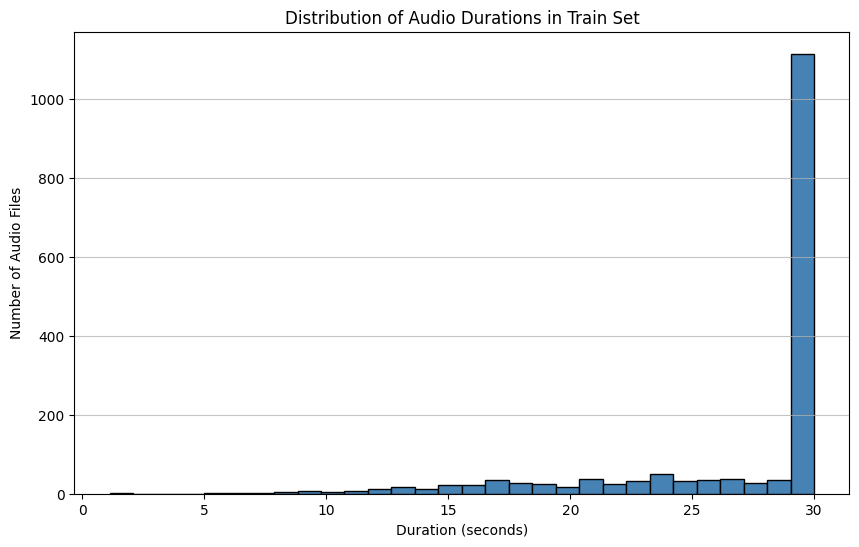


Audio Duration Statistics:
Min_duration: 1.11 seconds
Max_duration: 30.00 seconds
Mean_duration: 27.06 seconds
Median_duration: 30.00 seconds


In [31]:
# Analyzing audio file durations with librosa
audio_durations = []

for i, row in audio_files_with_labels.iterrows():
    file_path = row['file_path']
    try:
        # Load only metadata to calculate duration
        duration = librosa.get_duration(path=file_path)
        audio_durations.append(duration)
    except FileNotFoundError:
        print(f"File not found: {file_path}")
    except Exception as e:
        print(f"Error loading {file_path}: {e}")

# Visualization of duration distribution
if audio_durations:
    plt.figure(figsize=(10, 6))
    plt.hist(audio_durations, bins=30, color='steelblue', edgecolor='black')
    plt.title('Distribution of Audio Durations in Train Set')
    plt.xlabel('Duration (seconds)')
    plt.ylabel('Number of Audio Files')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

    # Calculation and display of duration statistics
    audio_duration_stats = {
        'min_duration': np.min(audio_durations),
        'max_duration': np.max(audio_durations),
        'mean_duration': np.mean(audio_durations),
        'median_duration': np.median(audio_durations)
    }

    print("\nAudio Duration Statistics:")
    for stat, value in audio_duration_stats.items():
        print(f"{stat.capitalize()}: {value:.2f} seconds")
else:
    print("No audio durations available. Possible issues with file loading.")
